# Étape 6 — Importance des features (globale et locale)

Deux niveaux d'interprétabilité : globale (quelles variables comptent pour le modèle) et locale (pourquoi telle décision pour un client). J'utilise SHAP sur le LightGBM optimisé de l'Étape 4. C'est l'objectif de transparence du projet (objectif 2 du brief).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import mlflow, shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import training

# Figures du livrable en 300 dpi (PNG sans perte) : le flou venait du dpi=110, pas d'une compression.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})
DPI = 300

training.setup_mlflow()
OUTPUT = PROJECT_ROOT / 'output'
FIG = OUTPUT / 'shap_figures'; FIG.mkdir(exist_ok=True)
model = mlflow.lightgbm.load_model('models:/credit-default-lgbm/latest')
X, y = training.load_training_data()
rng = np.random.RandomState(42)
idx = rng.choice(len(X), size=3000, replace=False)
X_s, y_s = X.iloc[idx], y.iloc[idx]
print('échantillon SHAP :', X_s.shape)

échantillon SHAP : (3000, 779)


## Importance globale

Trois angles complémentaires : le gain interne de LightGBM, les valeurs SHAP (effet moyen absolu de chaque variable), et l'importance par permutation comme contrôle.

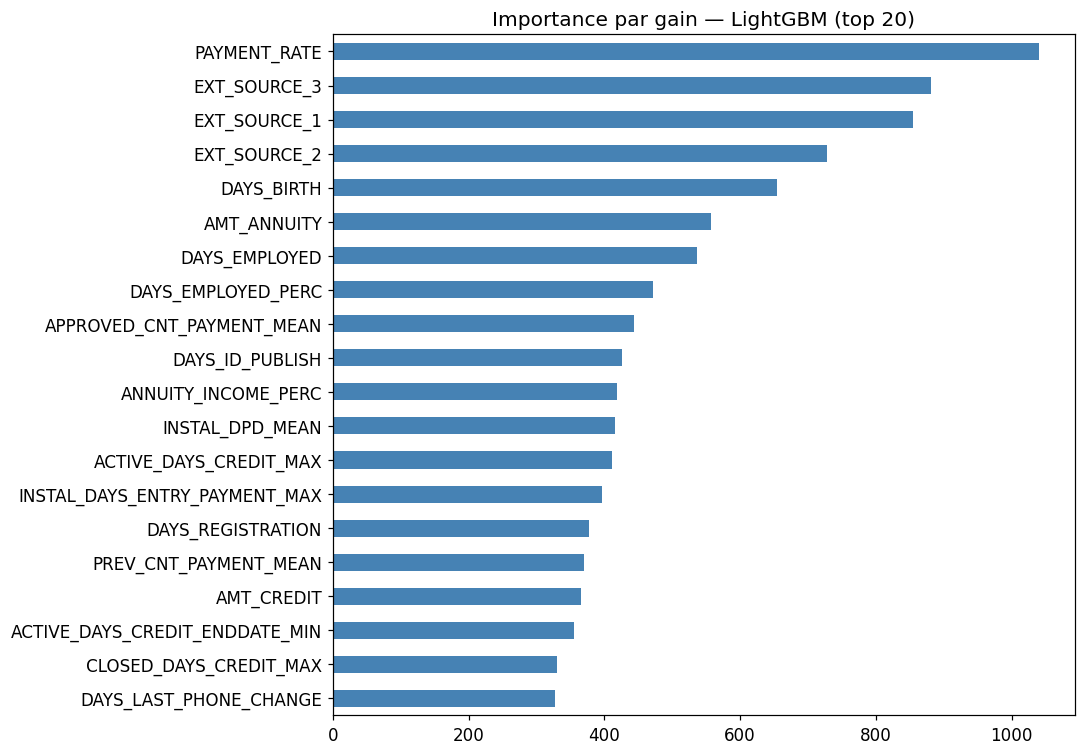

In [2]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
imp[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Importance par gain — LightGBM (top 20)')
plt.tight_layout(); plt.savefig(FIG / 'gain_importance.png', dpi=DPI, bbox_inches='tight'); plt.show()

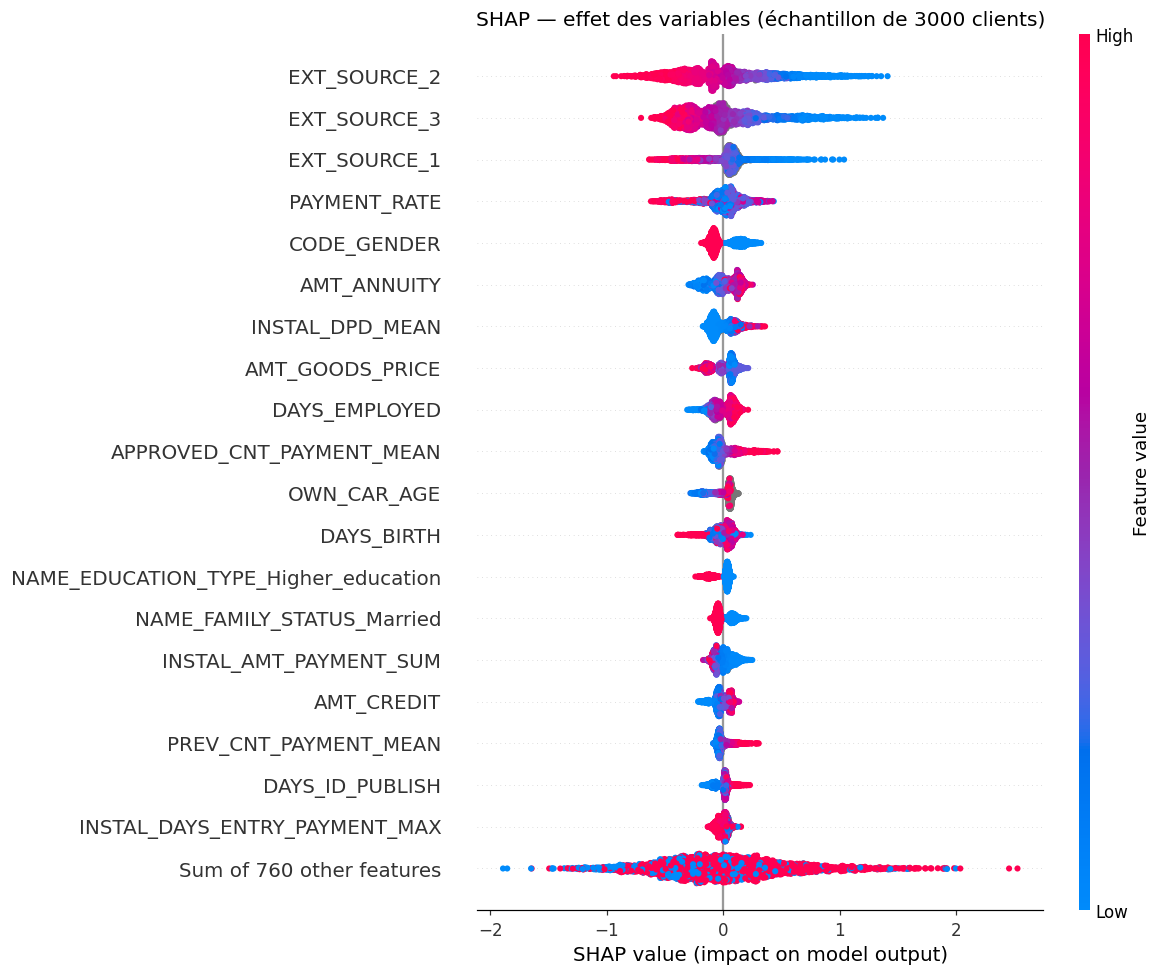

In [3]:
explainer = shap.TreeExplainer(model)
sv = explainer(X_s)
vals = sv[:, :, 1] if sv.values.ndim == 3 else sv
shap.plots.beeswarm(vals, max_display=20, show=False)
plt.gcf().set_size_inches(11, 9)
plt.title('SHAP — effet des variables (échantillon de 3000 clients)')
plt.tight_layout(); plt.savefig(FIG / 'shap_beeswarm.png', dpi=DPI, bbox_inches='tight'); plt.show()

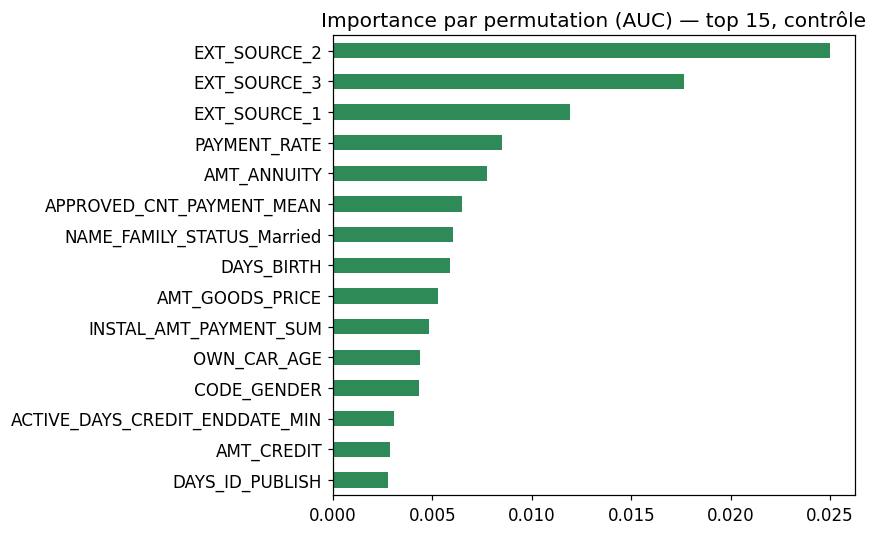

In [4]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, X_s, y_s, scoring='roc_auc', n_repeats=3, random_state=42, n_jobs=-1)
pi = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
pi[::-1].plot.barh(ax=ax, color='seagreen')
ax.set_title('Importance par permutation (AUC) — top 15, contrôle')
plt.tight_layout(); plt.show()

Les trois mesures se recoupent : les sources externes `EXT_SOURCE_*`, les ratios de paiement et l'historique de crédit dominent. C'est cohérent avec l'intuition métier (scores externes et capacité de remboursement).

## Importance locale — un client donné

Pour la transparence d'une décision, je prends le client le plus à risque et le moins à risque de l'échantillon, et je montre la contribution de chaque variable à sa probabilité de défaut (waterfall SHAP).

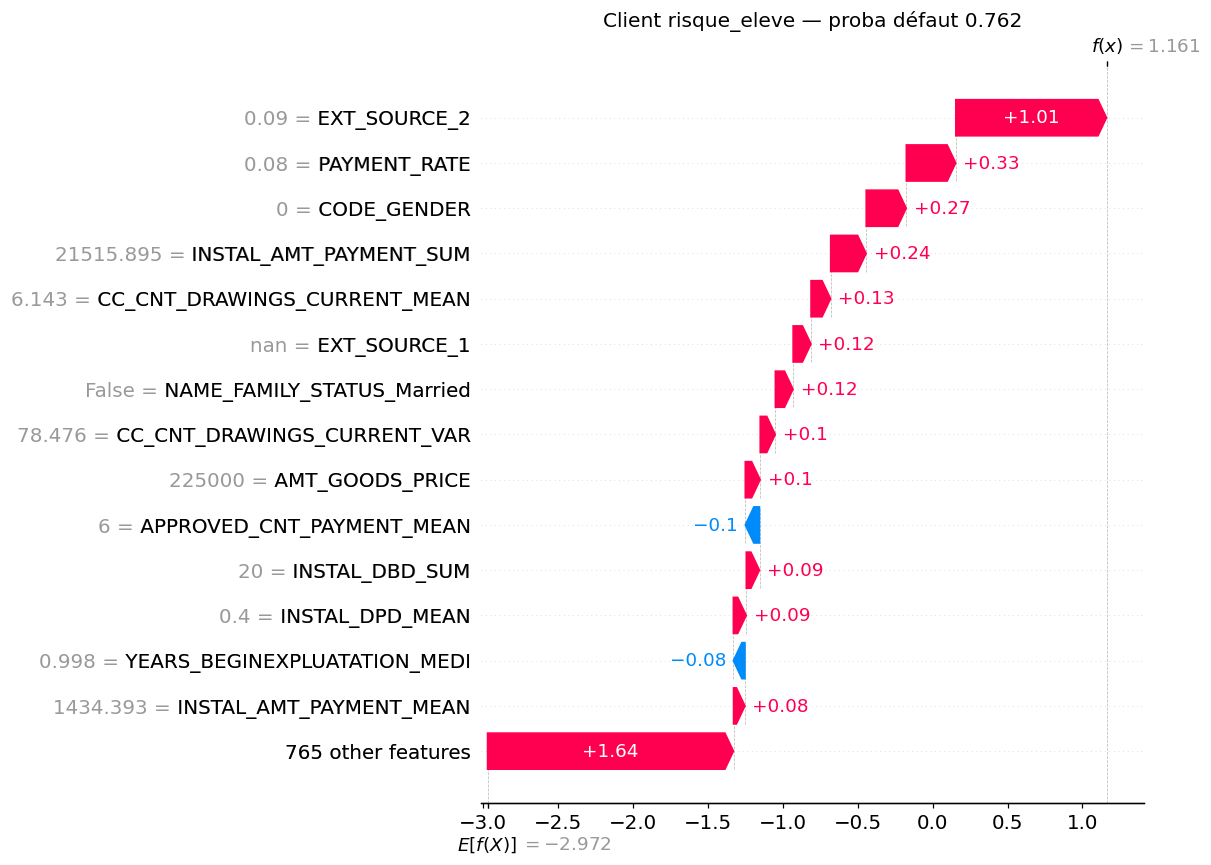

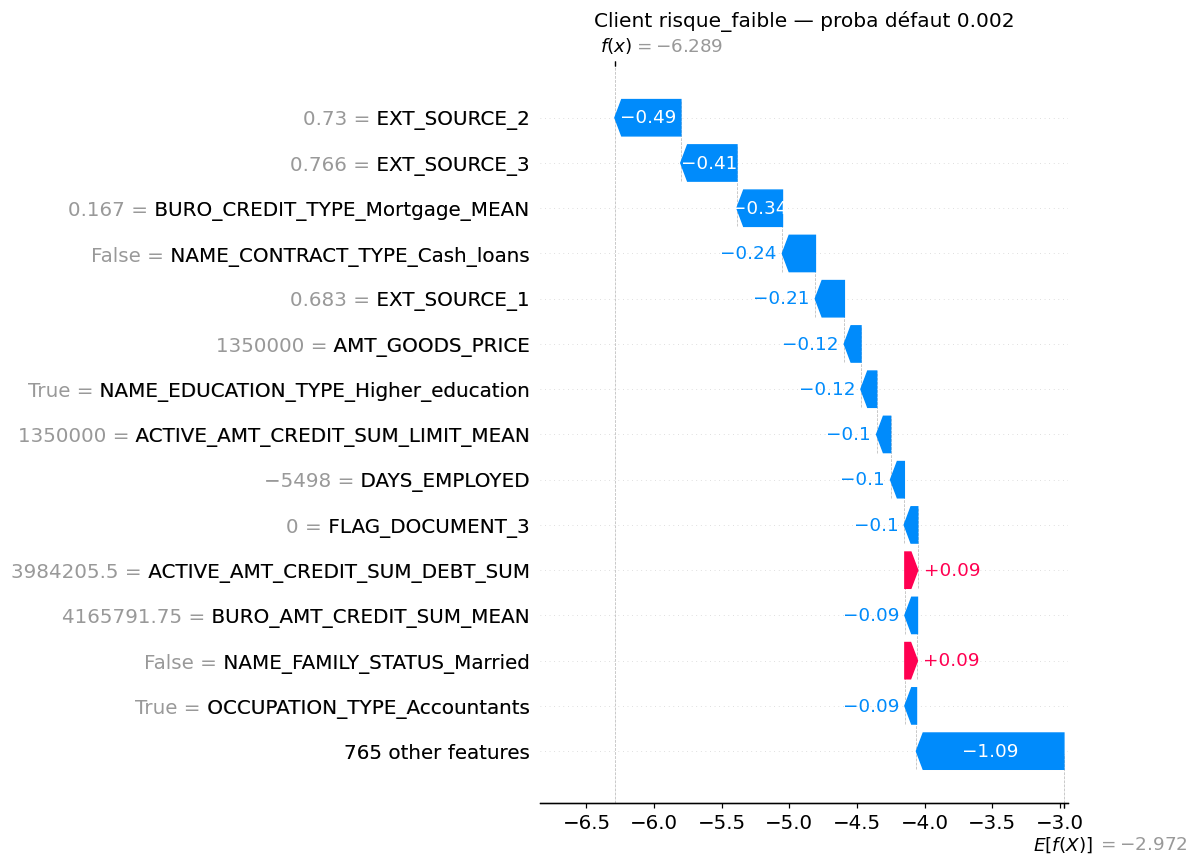

In [5]:
proba = model.predict_proba(X_s)[:, 1]
i_def, i_safe = int(np.argmax(proba)), int(np.argmin(proba))
for i, label in [(i_def, 'risque_eleve'), (i_safe, 'risque_faible')]:
    shap.plots.waterfall(vals[i], max_display=15, show=False)
    plt.gcf().set_size_inches(11, 8)
    plt.title(f'Client {label} — proba défaut {proba[i]:.3f}')
    plt.tight_layout(); plt.savefig(FIG / f'shap_waterfall_{label}.png', dpi=DPI, bbox_inches='tight'); plt.show()

In [6]:
import shutil
# Les noms figure_shap_N_* sont ceux du livrable : on les recopie depuis les versions 300 dpi.
deliverable = {
    'shap_beeswarm.png': 'figure_shap_1_importance_globale_beeswarm.png',
    'gain_importance.png': 'figure_shap_2_importance_globale_gain.png',
    'shap_waterfall_risque_eleve.png': 'figure_shap_3_explication_locale_risque_eleve.png',
    'shap_waterfall_risque_faible.png': 'figure_shap_4_explication_locale_risque_faible.png',
}
for src_name, dst_name in deliverable.items():
    shutil.copyfile(FIG / src_name, FIG / dst_name)
print('Copies livrable rafraichies :', *deliverable.values(), sep='\n  ')

Copies livrable rafraichies :
  figure_shap_1_importance_globale_beeswarm.png
  figure_shap_2_importance_globale_gain.png
  figure_shap_3_explication_locale_risque_eleve.png
  figure_shap_4_explication_locale_risque_faible.png


## Trace dans MLflow

Je logue les figures SHAP dans un run MLflow pour les retrouver à côté des modèles.

In [7]:
with mlflow.start_run(run_name='shap_analysis'):
    mlflow.set_tags({'step': '6', 'analysis': 'shap'})
    for f in FIG.glob('*.png'):
        mlflow.log_artifact(str(f), artifact_path='shap')
print('Figures SHAP loguées dans MLflow et sauvegardées dans', FIG)

Figures SHAP loguées dans MLflow et sauvegardées dans C:\Users\ClementLoire\ObsidianVault_MCP_enabled\05 - Cours\P6 - Initiez-vous au MLOps 1-2\output\shap_figures
